# OpenRouter

OpenRouter è un servizio che permette di **usare LLM diversi** tramite un’API compatibile OpenAI.

Per utilizzarla occorre creare un proprio account su https://openrouter.ai/, generare la **API Key** dal pannello utente da caricare poi nel file .env e da utilizzare poi nella configurazione.

In [ ]:
import os

# root della repo
os.chdir("/workspaces/hackaton-UNIBG-repo/")
os.getcwd()


In [2]:
from dotenv import load_dotenv

load_dotenv()
open_router_key = os.getenv("OPEN_ROUTER_KEY")

# print(open_router_key) # per testing

In [3]:
from openai import OpenAI

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=open_router_key, 
)


In [ ]:
response = client.chat.completions.create(
    model="openrouter/owl-alpha",  # Inserire qui l'id del modello che si vuole utilizzare
    messages=[
        {"role": "user", "content": "Ciao! Spiega brevemente in italiano cos'è una mela."}
    ],
)

print(response.choices[0].message.content)

Ciao! Una mela è un frutto prodotto dal melo (Malus domestica), un albero della famiglia delle Rosacee. È uno dei frutti più diffusi e consumati nel mondo, noto per la sua croccantezza, il sapore dolce o acidulo a seconda della varietà, e il colore che può variare dal verde al rosso. Le mele sono ricche di fibre, vitamine (soprattutto vitamina C) e antiossidanti. Vengono utilizzate sia per il consumo fresco che per la preparazione di succhi, torta di mele e altri prodotti derivati.


# LangGraph

LangGraph è una libreria Python progettata per **orchestrare sistemi multi-agente basati su LLM**. 
Permette di definire un grafo di nodi e transizioni, dove ogni nodo può essere un agente (o una funzione) che legge e aggiorna uno stato condiviso. In questo modo è possibile creare **workflow complessi**. 

In [ ]:
"""
ESEMPIO: comunicazione tra due agenti con LangGraph + OpenRouter

Flusso:
USER → ResearchAgent → WriterAgent → OUTPUT
"""

from typing import TypedDict, List

# Messaggi standard LangChain (HumanMessage, AIMessage, ecc.)
from langchain_core.messages import BaseMessage, HumanMessage

# Modello OpenAI-compatible (OpenRouter usa questa interfaccia)
from langchain_openai import ChatOpenAI

from langchain.agents import create_agent

# Core LangGraph
from langgraph.graph import StateGraph, START, END


In [9]:
# Definizione dello stato condiviso, dove tutti gli agenti leggono e scrivono. 


class AgentState(TypedDict):
    # Messaggi iniziali (prompt utente)
    messages: List[BaseMessage]

    # Output dell'agente di ricerca
    research_notes: str

    # Output finale dell'agente writer
    final_answer: str


In [ ]:
# Configurazione di OpenRouter e del modello LLM 

llm = ChatOpenAI(
    model="openrouter/owl-alpha",
    base_url="https://openrouter.ai/api/v1",
    api_key=open_router_key,
    temperature=0.7,
)

In [ ]:
# Definizione degli agent da utilizzare 

research_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt="""
    Sei un agente di ricerca.

    Regole:
    - Produci appunti chiari
    - Usa punti elenco
    - NON scrivere la risposta finale
    """
)

writer_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt="""
    Sei un writer professionale.

    Regole:
    - Scrivi SOLO usando le informazioni fornite
    - Stile chiaro e strutturato
    """
)

In [ ]:
# Definizione dei nodi del grafo  

def research_node(state: AgentState) -> dict:
    """
    Nodo che:
    - riceve lo stato
    - chiama il ResearchAgent
    - salva il risultato nello stato
    """

    result = research_agent.invoke({
        "messages": state["messages"]
    })

    # Prendiamo l'ultimo messaggio generato dall'agente
    research_text = result["messages"][-1].content

    return {
        "research_notes": research_text
    }


def writer_node(state: AgentState) -> dict:
    """
    Nodo che:
    - legge le note di ricerca
    - produce la risposta finale
    """

    original_request = state["messages"][-1].content

    prompt = f"""
    Richiesta utente:
    {original_request}

    Note di ricerca:
    {state['research_notes']}

    Scrivi una risposta finale completa usando esclusivamente queste informazioni.
    """

    result = writer_agent.invoke({
        "messages": [HumanMessage(content=prompt)]
    })

    final_text = result["messages"][-1].content

    return {
        "final_answer": final_text
    }

In [13]:
# Costruzione del grafo 

graph = StateGraph(AgentState)

# Aggiungiamo i nodi
graph.add_node("researcher", research_node)
graph.add_node("writer", writer_node)

# Definiamo il flusso
graph.add_edge(START, "researcher")
graph.add_edge("researcher", "writer")
graph.add_edge("writer", END)

# Compiliamo il grafo (diventa eseguibile)
app = graph.compile()



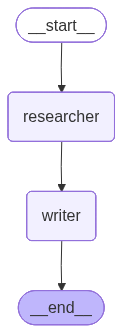

In [ ]:
# Visualizzazione del grafo. Questa cella funziona solo su notebook jupyter

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
# Salvataggio del file .png - Questo funziona anche in script python

png_data = app.get_graph().draw_mermaid_png()

with open("graph.png", "wb") as f:
    f.write(png_data)

In [ ]:
# Esecuzione del workflow di agenti

# Forniamo il messaggio iniziale 
result = app.invoke({
    "messages": [
        HumanMessage(content="Spiega cos'è LangGraph a un developer junior")
    ]
})

print("\n===== RISPOSTA FINALE =====\n")
print(result["final_answer"])


===== RISPOSTA FINALE =====

# Cos'è LangGraph?

LangGraph è un framework costruito su LangChain che permette di creare applicazioni AI basate su grafi, ovvero workflow a stati.

## Come funziona?

Invece di avere un flusso lineare, LangGraph ti permette di definire passaggi specifici all'interno di un grafo, dove ogni nodo rappresenta uno stato o un'operazione. Questo significa che puoi gestire agenti intelligenti con passaggi ben definiti, supportando anche cicli e decisioni condizionali nel flusso di lavoro.

## Perché è utile?

LangGraph è particolarmente ideale per casi d'uso complessi o interattivi, dove il flusso di lavoro non è sempre lineare e potrebbe richiedere di tornare indietro o prendere decisioni basate sui risultati precedenti.

## Esempio pratico

Immagina di voler creare un agente che risponde alle domande degli utenti. Con LangGraph puoi definire un grafo in cui:

1. **Nodo 1:** L'agente riceve la domanda
2. **Nodo 2:** L'agente cerca le informazioni
3. **Nodo 3:**